# Medical Insurance Charges Prediction
**Team Datawise | Case Study 1 (Healthcare) | Group 8**

Goal: Predict medical insurance charges using personal and health-related information (age, sex, BMI, children, smoker status, region).


## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2. Initial Inspection

In [2]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSummary statistics:\n", df.describe())

Shape: (1338, 7)

Data types:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1

Summary statistics:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


**Interpretation:**
The dataset has 1338 rows and 7 columns, with no missing values. There is exactly 1 duplicate row, which we remove below. The average age is ~39, average BMI is ~30.7 (borderline obese), and average charges are ~$13,270, with a wide spread (min ~$1,122 up to over $60,000).

<span style = "font-size:35px">Distribution of Numerical Variables</span>

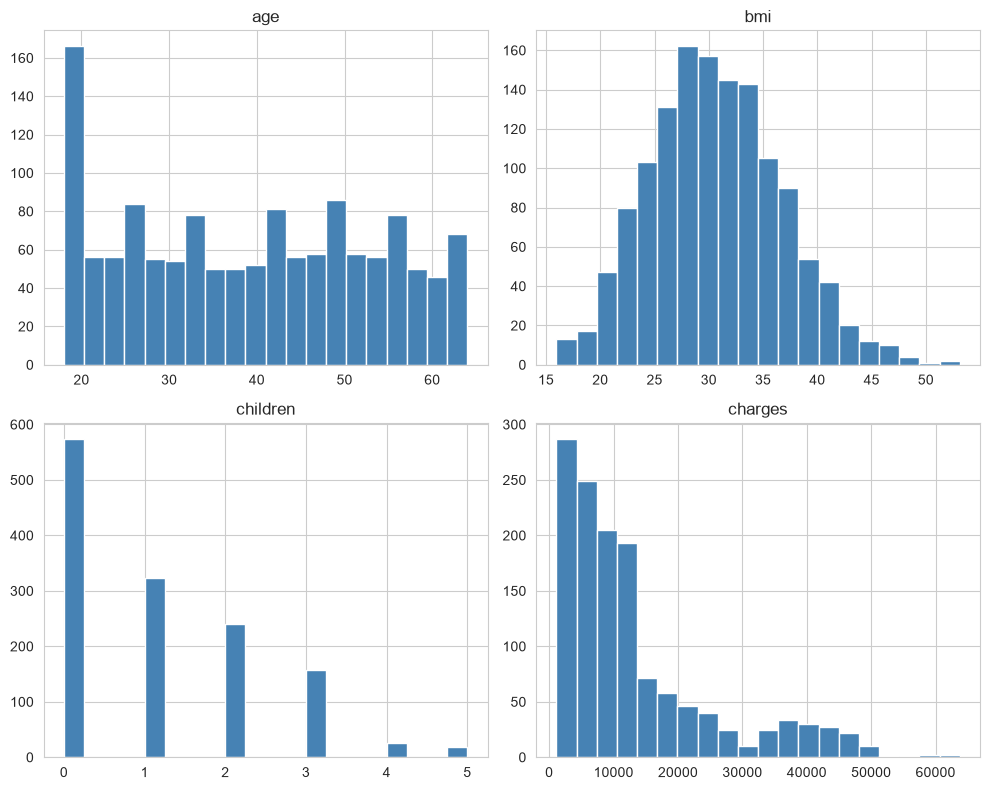

In [3]:
df.hist(figsize =(10, 8), bins=20, color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

## 3. Clean Data; Remove Duplicate

In [4]:
df = df.drop_duplicates()
print("New shape after removing duplicate:", df.shape)

New shape after removing duplicate: (1337, 7)


## 4. Category Counts

In [5]:
print(df['smoker'].value_counts())
print()
print(df['region'].value_counts())
print()
print(df['sex'].value_counts())

smoker
no     1063
yes     274
Name: count, dtype: int64

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

sex
male      675
female    662
Name: count, dtype: int64


## 5. Grouped Comparisons

In [6]:
print("Average charges by smoker status:")
print(df.groupby('smoker')['charges'].mean())

print("\nAverage charges by region:")
print(df.groupby('region')['charges'].mean())

print("\nAverage charges by smoker + obesity (BMI >= 30):")
df['obese'] = df['bmi'] >= 30
print(df.groupby(['smoker', 'obese'])['charges'].mean())

Average charges by smoker status:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

Average charges by region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

Average charges by smoker + obesity (BMI >= 30):
smoker  obese
no      False     7977.029520
        True      8855.531349
yes     False    21363.217016
        True     41557.989840
Name: charges, dtype: float64


**Interpretation:**
Smokers pay dramatically more than non-smokers (~$32,050 vs ~$8,434 on average nearly 4x higher). Region shows only minor differences. Most strikingly, smoking and obesity interact: obese smokers pay nearly double non-obese smokers (~$41,558 vs ~$21,363), while obesity barely changes charges for non-smokers (~$8,843 vs ~$7,977). This shows BMI amplifies cost specifically when combined with smoking, rather than acting as an independent driver on its own.

## 6. Correlation with Charges

In [7]:
print(df.corr(numeric_only=True)['charges'].sort_values(ascending=False))

charges     1.000000
age         0.298308
obese       0.200347
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


**Interpretation:**
Among numeric variables, age shows the strongest positive correlation with charges, followed by BMI. Number of children shows almost no correlation. Note this doesn't capture smoker status (a categorical variable), which our grouped comparison above shows is actually the most influential factor overall.

## 7. Visualizations

### 7.1 Distribution of Charges

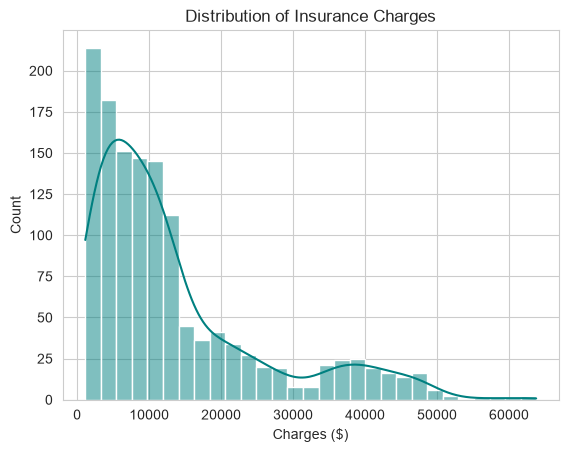

In [8]:
sns.histplot(df['charges'], kde=True, color='teal')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.show()

**Interpretation:** The distribution of charges is right-skewed most customers pay under $15,000, while a smaller group incurs very high charges (above $40,000).

### 7.2 Charges by Smoking Status

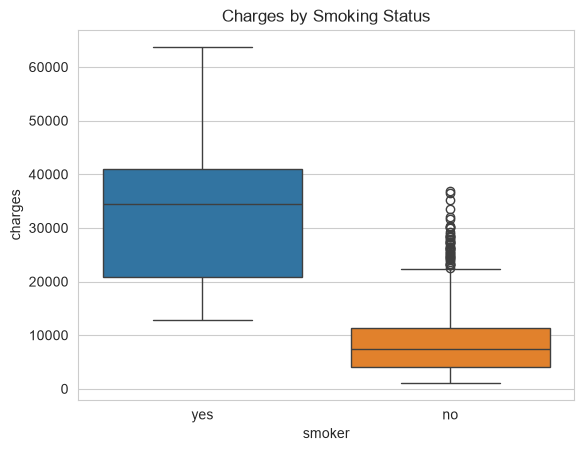

In [9]:
sns.boxplot(data=df, x='smoker', y='charges', hue='smoker', legend=False)
plt.title('Charges by Smoking Status')
plt.show()

**Interpretation:** Smokers pay significantly more than non-smokers on average, nearly 4x higher. Smoking status is clearly one of the strongest predictors of medical charges in this dataset.

### 7.3 Age vs Charges (by Smoker Status)

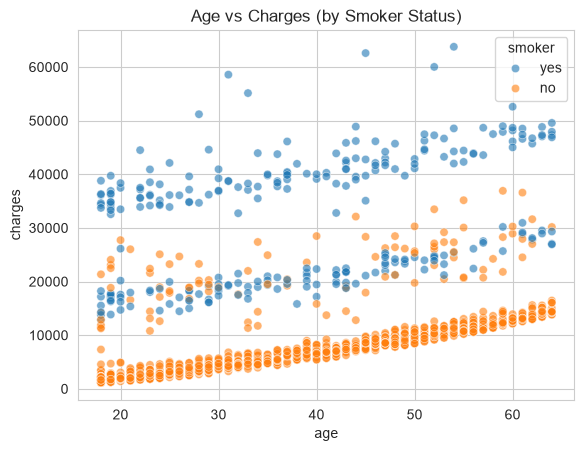

In [10]:
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6)
plt.title('Age vs Charges (by Smoker Status)')
plt.show()

**Interpretation:** Charges increase steadily with age for both smokers and non-smokers, but smokers consistently sit far above non-smokers at every age. Smokers also split into two visible cost bands, hinting that another factor (BMI) further separates high-cost from lower-cost smokers.

### 7.4 BMI vs Charges (by Smoker Status)

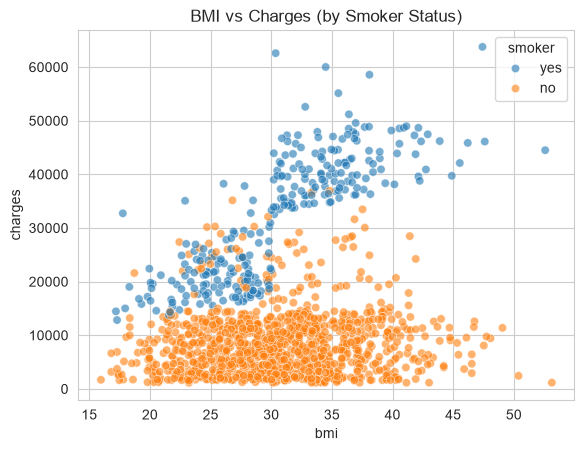

In [11]:
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title('BMI vs Charges (by Smoker Status)')
plt.show()

**Interpretation:** For non-smokers, BMI has little effect on charges. For smokers, charges rise sharply from $20k up into he $40k-$60k cluster just as BMI increases. This is an interaction effect: BMI amplifies cost specifically when combined with smoking.

### 7.5 Charges by Region

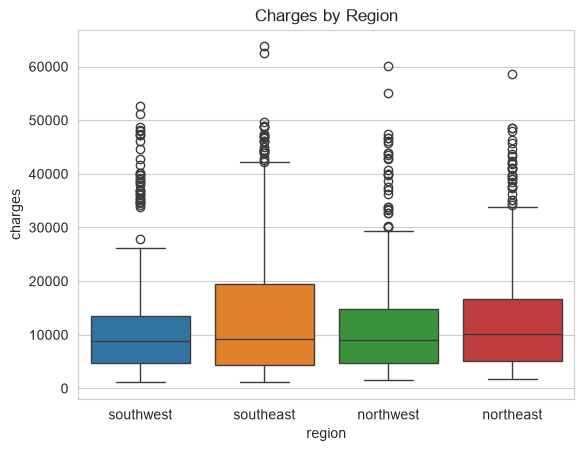

In [12]:
sns.boxplot(data=df, x='region', y='charges', hue='region', legend=False)
plt.title('Charges by Region')
plt.show()

**Interpretation:** Charges are fairly similar across all four regions, with only minor variation. Region does not appear to be a strong predictor of medical costs.

### 7.6 Correlation Heatmap

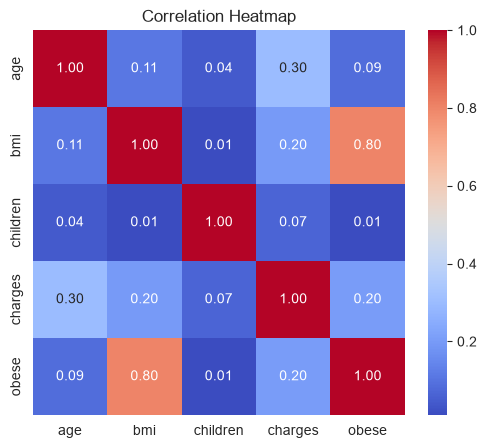

In [13]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**Interpretation:** Age and BMI show the clearest positive relationships with charges among numeric variables. Children shows almost no relationship. As noted earlier, this heatmap alone understates the importance of smoker status since it's categorical.

## 8. Prepare Data for Modeling

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Encode categorical variables into numbers
df_encoded = pd.get_dummies(df.drop(columns=['obese']), columns=['sex', 'smoker', 'region'], drop_first=True)

# Separate features (X)input from target (y)output
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1069
Testing rows: 268


## 9. Train the Regression Model

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 10. Evaluate the Model

In [16]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)
print("intercept", model.intercept_)

R2 Score: 0.8069287081198012
MAE: 4177.045561036319
RMSE: 5956.342894363587
intercept -11092.652295945965


**Interpretation:** The R2 score shows what percentage of the variation in charges the model explains. MAE shows the average size of prediction error in dollars. RMSE is similar but penalizes large errors more heavily.

## 11. Which Features Matter Most

In [17]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)
coefficients

,Feature,Coefficient
4,smoker_yes,23077.764593
6,region_southeast,-838.919616
7,region_southwest,-659.139752
2,children,533.009989
5,region_northwest,-391.761455
1,bmi,318.701441
0,age,248.210720
3,sex_male,-101.542054


**Interpretation:** Smoker status has by far the largest coefficient, confirming it as the single biggest driver of medical charges. Age, BMI, and number of children have smaller positive effects. Sex and region have minimal impact on predicted charges.

## 12. Conclusion

- The dataset contains 1338 records (1337 after removing 1 duplicate) with no missing values.
- **Smoking status** is the strongest single predictor of medical insurance charges smokers pay nearly 4x more on average than non-smokers.
- **BMI interacts with smoking**: obese smokers pay nearly double what non-obese smokers pay, while BMI has little effect on non-smokers' charges.
- **Age** contributes a steady increase in charges as people get older.
- **Sex, region, and number of children** have minimal effect on charges.
- Our Linear Regression model explains a strong majority of the variation in charges, with predictions typically accurate to within a few thousand dollars.
- **Business takeaway:** insurers (and health programs) should treat smoking  especially combined with high BMI  as the primary risk factor driving cost, rather than age or demographic factors alone.

## Addding Individual MAE to EXISTING old model table

In [18]:
comparison = pd.DataFrame({'Actual': y_test, 'Predictory': y_pred})
comparison.index = comparison.index + 2
comparison['Individual_MAE']= np.abs(comparison['Actual']-comparison['Predictory'])
comparison.head(10)


,Actual,Predictory,Individual_MAE
902,8688.85885,8143.693884,545.164966
1066,5708.86700,5737.115683,28.248683
1258,11436.73815,14369.314876,2932.576726
300,38746.35510,31745.513636,7000.841464
239,4463.20510,8962.386657,4499.181557
483,9304.70190,13149.722353,3845.020453
242,38511.62830,30446.760679,8064.867621
279,2150.46900,1453.288813,697.180187
417,7345.72660,10633.018402,3287.291802
709,10264.44210,11318.943794,1054.501694


In [19]:
print("Overall MAE (Old Model): $", round(comparison['Individual_MAE'].mean(), 2))

Overall MAE (Old Model): $ 4177.05


## 13. Investigating Prediction Errors

"Our model's largest prediction errors occur specifically among obese smokers the highest-risk group. While Linear Regression captures the general effect of smoking well, it underestimates just how extreme the smoking + obesity combination can push charges. This suggests a more flexible model (e.g., adding an interaction term between smoker and BMI, or trying a non-linear model) could improve accuracy for this specific task." So let's actually build it and see if it improves the model.

In [20]:
# Create an interaction term: smoker status multiplied by BMI
# For non-smokers this is always 0; for smokers it scales with their BMI
df_encoded['smoker_bmi'] = df_encoded['smoker_yes'] * df_encoded['bmi']

# Rebuild X to include the new feature
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

r2_new = r2_score(y_test, y_pred2)
mae_new = mean_absolute_error(y_test, y_pred2)
rmse_new = np.sqrt(mean_squared_error(y_test, y_pred2))

print("Improved model R2:", r2_new)
print("Improved model MAE:", mae_new)
print("Improved model RMSE:", rmse_new)

Improved model R2: 0.8862045574393044
Improved model MAE: 2828.9737471039484
Improved model RMSE: 4572.8112393546735


<span style = "font-size:35px">New table for the IMPROVED model :</span>


In [21]:
comparison_new = pd.DataFrame({'Actual': y_test, 'Predictory': y_pred2})
comparison_new.index = comparison_new.index + 2
comparison_new['Individual_MAE'] = np.abs(comparison_new['Actual'] - comparison_new['Predictory'])
comparison_new.head(10)

,Actual,Predictory,Individual_MAE
902,8688.85885,10490.964350,1802.105500
1066,5708.86700,7391.589659,1682.722659
1258,11436.73815,13101.645583,1664.907433
300,38746.35510,36341.057227,2405.297873
239,4463.20510,6270.895715,1807.690615
483,9304.70190,10922.695030,1617.993130
242,38511.62830,38179.329701,332.298599
279,2150.46900,3281.875560,1131.406560
417,7345.72660,9422.395370,2076.668770
709,10264.44210,11840.065709,1575.623609


 <span style = "font-size:35px">A glance on our model's performance</span>


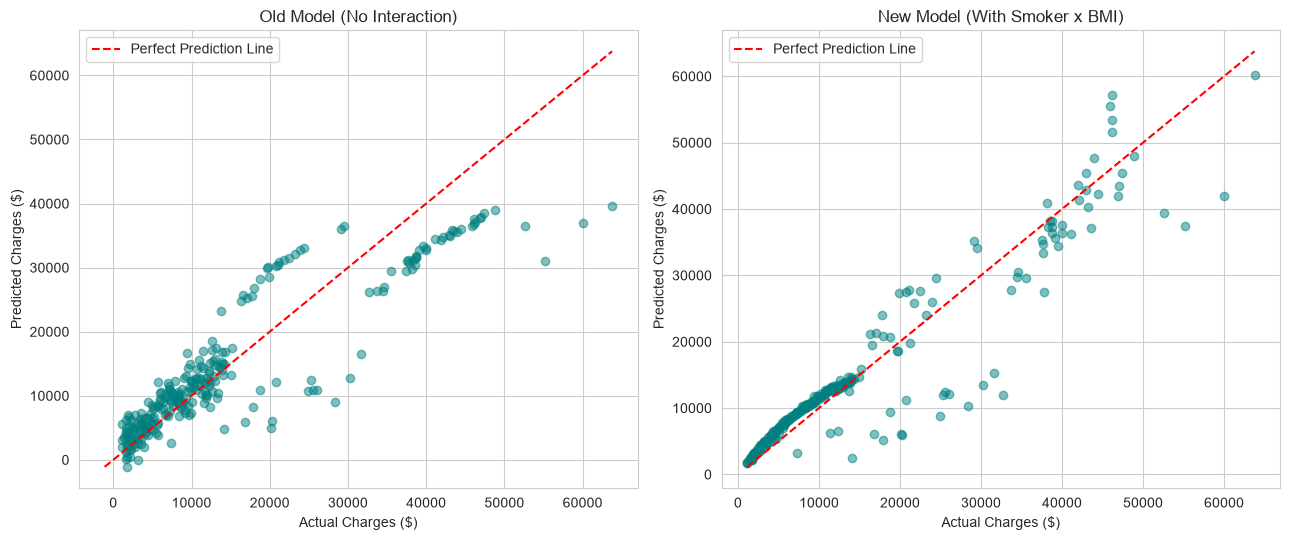

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, pred, title in zip(axes, [y_pred, y_pred2], ['Old Model (No Interaction)', 'New Model (With Smoker x BMI)']):
    ax.scatter(y_test, pred, alpha=0.5, color='teal')
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='Perfect Prediction Line')
    ax.set_xlabel('Actual Charges ($)')
    ax.set_ylabel('Predicted Charges ($)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

#### Both scatter plots compare actual charges (x-axis) to predicted charges (y-axis), with the red dashed line representing perfect prediction. In the old model, points for high-charge individuals (mainly obese smokers) scatter noticeably above and below the line. In the new model, these same points cluster much more tightly around the line, visually confirming the improvement captured by our MAE and R² scores.

## 14.2 Residual Plots: Checking for Error Patterns in our models

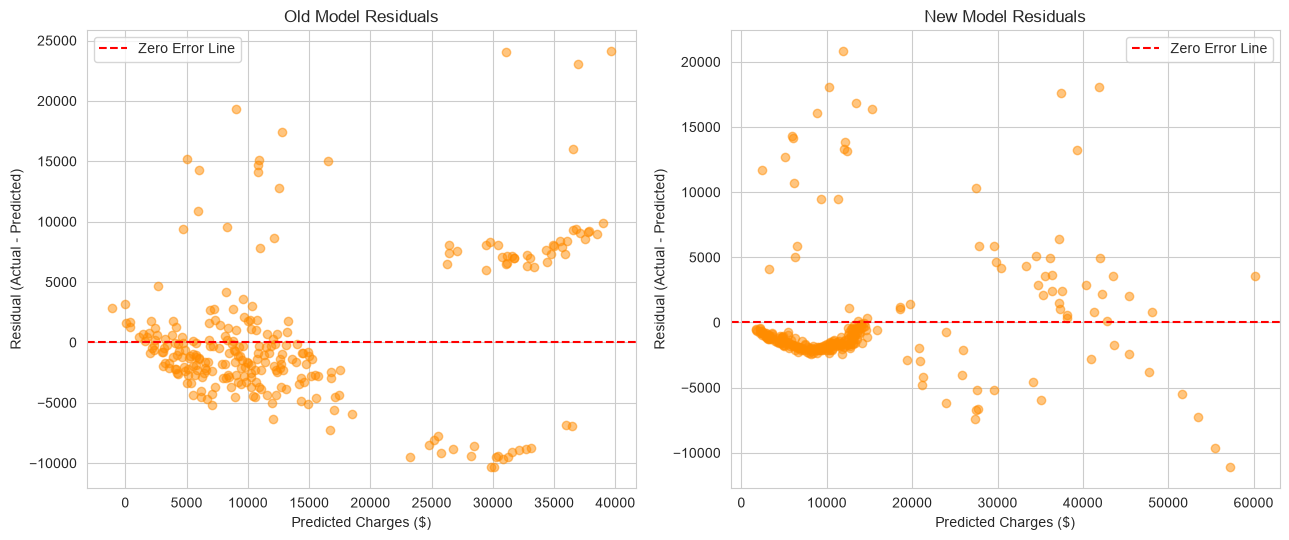

In [23]:
resid1 = y_test - y_pred      # old model errors
resid2 = y_test - y_pred2     # new model errors

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, pred, resid, title in zip(axes, [y_pred, y_pred2], [resid1, resid2], ['Old Model Residuals', 'New Model Residuals']):
    ax.scatter(pred, resid, alpha=0.5, color='darkorange')
    ax.axhline(0, color='red', linestyle='--', label='Zero Error Line')
    ax.set_xlabel('Predicted Charges ($)')
    ax.set_ylabel('Residual (Actual - Predicted)')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()